<a href="https://colab.research.google.com/github/RichardGonow/RichardGonow/blob/main/%E6%9D%90%E6%96%99%E6%95%B0%E6%8D%AE%E6%8C%96%E6%8E%98-%E5%A4%A7%E4%BD%9C%E4%B8%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!ls


sample_data  test.dat  train.dat


In [8]:
import pandas as pd

train_df = pd.read_csv("train.dat", sep=r"\s+")
test_df  = pd.read_csv("test.dat",  sep=r"\s+")

print(train_df.head())
print(train_df.shape)

#读取数据

   id  E_bandgap  spacegroup  N_total_atoms  percent_Al  percent_Ga  \
0  s1     3.4387          33             80      0.6250      0.3750   
1  s2     2.9210         194             80      0.6250      0.3750   
2  s3     2.7438         227             40      0.8125      0.1875   
3  s4     3.3492         167             30      0.7500      0.0000   
4  s5     1.3793         194             80      0.0000      0.6250   

   percent_In  lattice_va  lattice_vb  lattice_vc  lattice_alpha  \
0       0.000      9.9523      8.5513      9.1775        90.0026   
1       0.000      6.1840      6.1838     23.6287        90.0186   
2       0.000      9.7510      5.6595     13.9630        90.9688   
3       0.250      5.0036      5.0034     13.5318        89.9888   
4       0.375      6.6614      6.6612     24.5813        89.9960   

   lattice_beta  lattice_gamma  
0       90.0023        90.0017  
1       89.9980       120.0025  
2       91.1228        30.5185  
3       90.0119       120.0017  

In [9]:
y_train = train_df["E_bandgap"]
y_test  = test_df["E_bandgap"]



In [11]:
#划分特征和标签，去掉id和 E——bandage
X_train = train_df.drop(columns=["id", "E_bandgap"])
X_test  = test_df.drop(columns=["id", "E_bandgap"])
print(X_train.columns)
print(X_train.shape)


Index(['spacegroup', 'N_total_atoms', 'percent_Al', 'percent_Ga', 'percent_In',
       'lattice_va', 'lattice_vb', 'lattice_vc', 'lattice_alpha',
       'lattice_beta', 'lattice_gamma'],
      dtype='object')
(2400, 11)


In [12]:
#标准化
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [15]:
#使用线性模型
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R2 =", r2_score(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))



R2 = 0.7838915700891802
RMSE = 0.48970288850852195


In [17]:
#使用回归森林模型
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)   # RF 不需要标准化
y_pred = rf.predict(X_test)

print("R2 =", r2_score(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))



R2 = 0.9404779852781321
RMSE = 0.25700147930054457


In [19]:
#L2正则
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)

print("Ridge Regression")
print("R2 =", r2_score(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))


Ridge Regression
R2 = 0.7831757186580797
RMSE = 0.49051327960176083


In [20]:
#Lasso Regression（特征选择）
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

print("Lasso Regression")
print("R2 =", r2_score(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))


Lasso Regression
R2 = 0.7791546045161812
RMSE = 0.49504079116566163


In [21]:
#SVR（RBF 核，强非线性
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

svr = SVR(
    kernel="rbf",
    C=100,
    gamma="scale"
)

svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

print("SVR (RBF)")
print("R2 =", r2_score(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))


SVR (RBF)
R2 = 0.9511411503879613
RMSE = 0.23284581158987241


In [22]:
#CNN（神经网络）
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    max_iter=2000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

print("MLP Regressor")
print("R2 =", r2_score(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))


MLP Regressor
R2 = 0.9484601531342768
RMSE = 0.23914889228032005


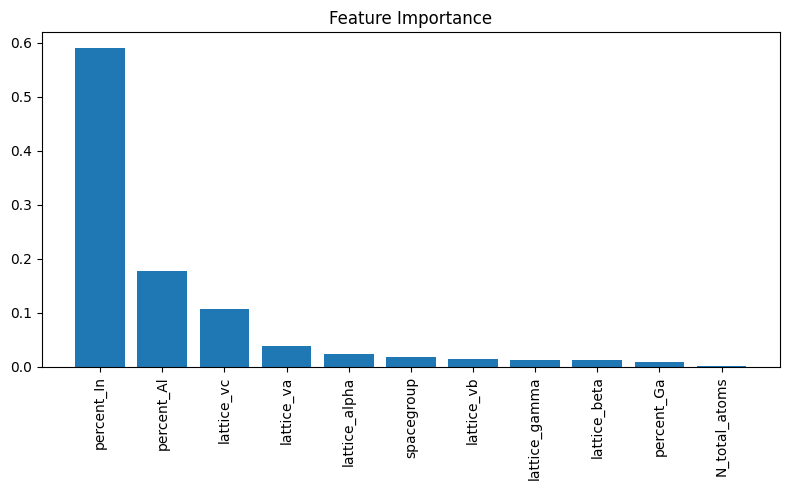

In [18]:
#看特征重要性
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()
